<h1 align="center">Life Satisfaction Prediction using GDP per Capita</h1>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

import warnings
warnings.filterwarnings("ignore")

## Part 1: Data Exploration and Visualization

#### **Q1 (5 marks)** Load the dataset `lifesat.csv` and display first 5 rows

In [2]:
df = pd.read_csv("lifesat.csv")
df.head()

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6


##### **Q2 (5 marks)** Print basic `info` and `summary statistics`

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               27 non-null     str    
 1   GDP per capita (USD)  27 non-null     float64
 2   Life satisfaction     27 non-null     float64
dtypes: float64(2), str(1)
memory usage: 780.0 bytes


In [4]:
df.describe()

,GDP per capita (USD),Life satisfaction
count,27.000000,27.000000
mean,41564.521771,6.566667
std,9631.452319,0.765607
min,26456.387938,5.400000
25%,33938.289305,5.900000
50%,41627.129269,6.800000
75%,49690.580269,7.300000
max,60235.728492,7.600000


#### **Q3 (10 marks)** Display a scatter plot for `GPD per capita` vs `Life Satisfaction`. And labels, title, and discuss the observed relationship.

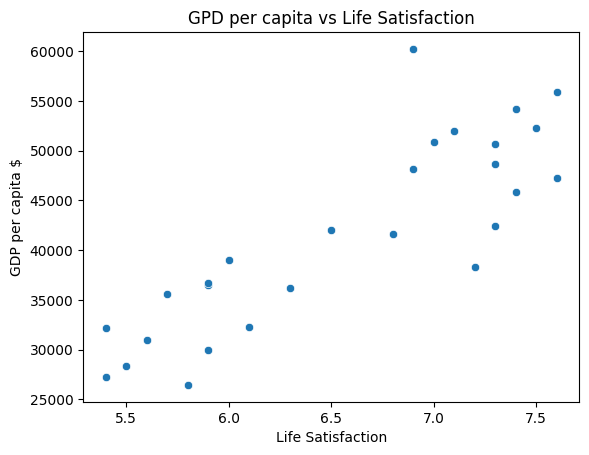

In [5]:
plt.title("GPD per capita vs Life Satisfaction")
sns.scatterplot(x='Life satisfaction', y='GDP per capita (USD)', data=df)
plt.xlabel("Life Satisfaction")
plt.ylabel("GDP per capita $")
plt.show()

##### **Discuss the observation relationship**

We have positive correlation betweem `GDP per capita` and `Life Satisfaction`, so we can draw a line.

## Part 2: Linear Regression Model

#### **Q4 (5 marks)** Extract input (X) and target (y). Print their shapes.

In [6]:
X = df[['GDP per capita (USD)']]
y = df[['Life satisfaction']]
print(X.shape, y.shape)

(27, 1) (27, 1)


#### **Q5 (10 marks)** Train a Linear Regression model & Display Cofficient and intercept

In [7]:
model = LinearRegression()
model.fit(X, y)

print("Coefficient (slope)", model.coef_[0])
print("Intercept", model.intercept_)

Coefficient (slope) [6.77889969e-05]
Intercept [3.74904943]


#### **Q6 (10 marks)** Plot the predicted regression line from the model along with a scatter plot of the data

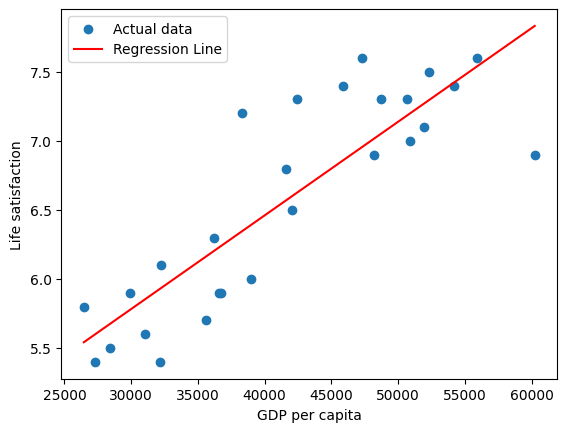

In [8]:
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = model.predict(X_range)

plt.scatter(X, y, label="Actual data")
plt.plot(X_range, y_pred, color='red', label="Regression Line")

plt.xlabel("GDP per capita")
plt.ylabel("Life satisfaction")
plt.legend()
plt.show()

#### **Q7 (5 marks)** Predict Life Satisfaction per GDP = 37,655.2 USD. Comment on result

In [9]:
GDP = [[37_655.2]]
prediction = model.predict(GDP)

print("Predicted Life Satisfaction:", prediction[0])

Predicted Life Satisfaction: [6.30165767]


The predicted `Life Satisfaction` for `GDP = 37,655.2` is approximately `6.30165767`.

## Part 3: K-Neares Neighbors Regression

#### **Q8 (5 marks)** Train a KNeighborsRegression (n_neighbors = 3)

In [10]:
knn = KNeighborsRegressor(n_neighbors = 3)
knn.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### **Q9 (10 marks)**
- Predict Life Satisfaction for GDP = 37,655.2 USD
- Compare with Linear Regression

In [11]:
knn_prediction = knn.predict(GDP)
print("Predicted by 3 neighbors:", knn_prediction[0])

Predicted by 3 neighbors: [6.33333333]


Compared `KNN` with `Linear Regression` we can assume that there aren't big difference between predected result. The spread was `~0.03` of `Life Satisfaction Level`.

#### **Q10 (10 marks)**
- Use n_neighbors 1, 3, 5 and 10 and print the predicted values of life satisfaction
- Plot the results using a line plot.

In [12]:
knn1 = KNeighborsRegressor(n_neighbors = 1)
knn5 = KNeighborsRegressor(n_neighbors = 5)
knn10 = KNeighborsRegressor(n_neighbors = 10)

knn1.fit(X, y)
knn5.fit(X, y)
knn10.fit(X, y)

print("Predicted by 1 neighbor:", knn1.predict(GDP)[0])
print("Predicted by 3 neighbors:", knn.predict(GDP)[0])
print("Predicted by 5 neighbors:", knn5.predict(GDP)[0])
print("Predicted by 10 neighbors:", knn10.predict(GDP)[0])

Predicted by 1 neighbor: [7.2]
Predicted by 3 neighbors: [6.33333333]
Predicted by 5 neighbors: [6.26]
Predicted by 10 neighbors: [6.37]


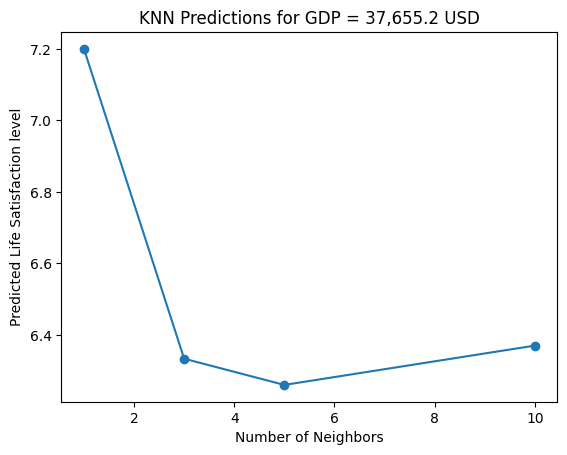

In [13]:
neighbors = [1, 3, 5, 10]
predictions = [7.2, 6.33333333, 6.26, 6.37]

plt.plot(neighbors, predictions, marker='o')
plt.xlabel("Number of Neighbors")
plt.ylabel("Predicted Life Satisfaction level")
plt.title("KNN Predictions for GDP = 37,655.2 USD")
plt.show()

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               27 non-null     str    
 1   GDP per capita (USD)  27 non-null     float64
 2   Life satisfaction     27 non-null     float64
dtypes: float64(2), str(1)
memory usage: 780.0 bytes


AttributeError: module 'matplotlib.pyplot' has no attribute 'line'

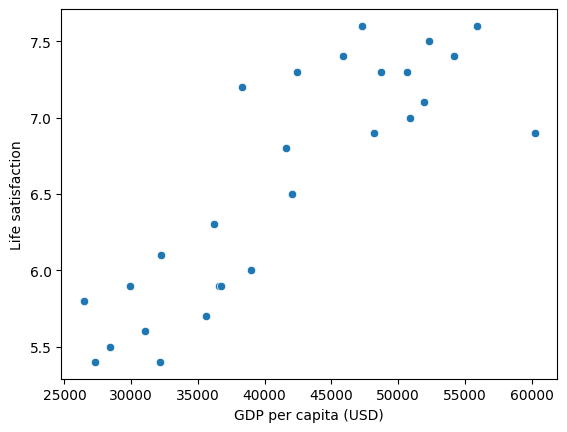

In [16]:
sns.scatterplot(x=df["GDP per capita (USD)"], y=df["Life satisfaction"])
plt.line(predicted)

In [ ]:
sns.scatterplot(data=df, x="GDP per capita (USD)", y="Life satisfaction")
plt.plot(X, m)